<a href="https://colab.research.google.com/github/Lucas-msongelwa/lucasmsongelwa.github.io/blob/main/Superstore_Sales_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Superstore Sales Dataset

Import Liraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.metrics import mean_squared_error

Load Data

In [ ]:
df = pd.read_csv('Superstore.csv')

Preview Data

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Shape of Data

In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Columns Names

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Checking Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

Remove duplicate

In [ ]:
df = df.drop_duplicates()

Convert Order Date to datetime

Total Sales

In [ ]:
df.Sales.sum()

np.float64(2261536.7827000003)

Sales by Category

In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending = True)

,Sales
Category,
Office Supplies,705422.3340
Furniture,728658.5757
Technology,827455.8730



Visualisation Sales Per Catergory

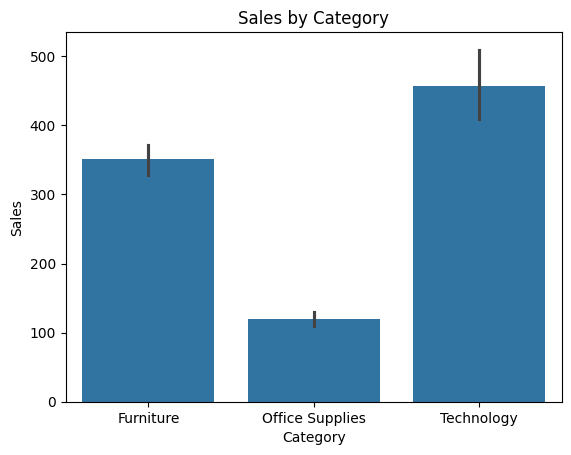

In [ ]:
plt.figure()
sns.barplot(x ='Category' , y ='Sales' , data = df)
plt.title('Sales by Category')
plt.show()

**Insight**

 Technology Products generates hight sales , indicating strong customer demand

**Recommendation **

Increase Marketing focus on technology Products to maximum Revenue


**How will Sales change in future  building a model to predit Sales**

Create Year , Month and Day Column

In [ ]:
df['Order_Month'] = df['Order Date'].dt.to_period('M')
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Day'] = df['Order Date'].dt.day

In [ ]:
df['Order_Month'].head()

,Order_Month
0,2017-11
1,2017-11
2,2017-06
3,2016-10
4,2016-10


Aggregate Monthly Sales

Checking Sales in 2015 , 2016 , 2017 and 2018

In [ ]:
Yearly_Sales = df.groupby('Order_Year')['Sales'].sum().reset_index()

In [ ]:
Yearly_Sales.head()

,Order_Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


Sales Per Year Visualisation

<Figure size 640x480 with 0 Axes>

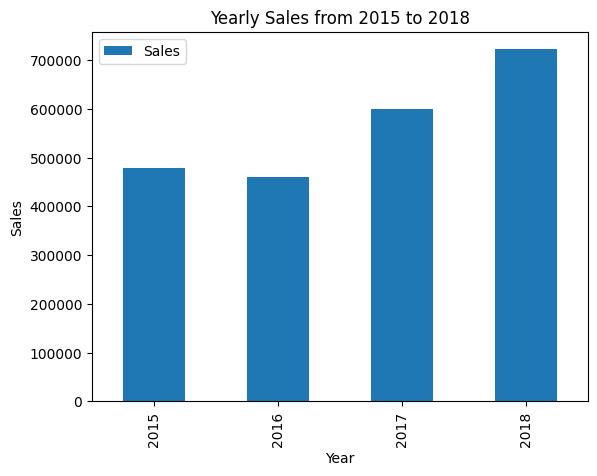

In [ ]:
plt.figure()
Yearly_Sales.plot(x = 'Order_Year' , y = 'Sales' , kind = 'bar')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Yearly Sales from 2015 to 2018')
plt.show()

Checking Sales Monthly from 2015 to 2018

In [ ]:
Monthly_Sales = df.groupby('Order_Month')['Sales'].sum().reset_index()

In [ ]:
Monthly_Sales.head()

,Order_Month,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


Monthly Sales Visualisation from 2015 to 2018

<Figure size 640x480 with 0 Axes>

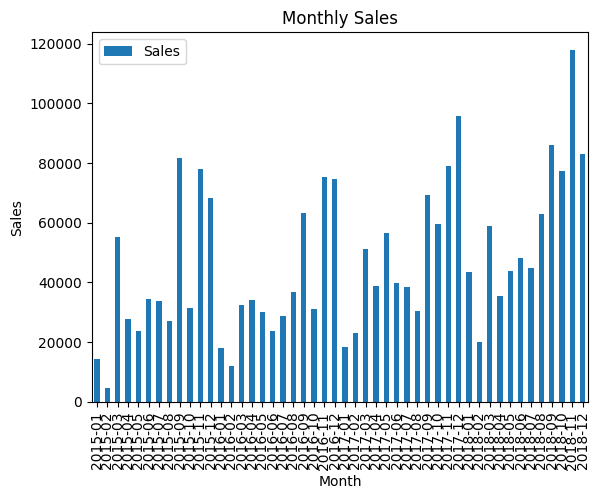

In [ ]:
plt.figure()
Monthly_Sales.plot(x = 'Order_Month' , y = 'Sales' , kind = 'bar')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.show()

Checking Sales Per Region

In [ ]:
Sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending = False).reset_index()

Visualisation  Sales per Region

<Figure size 640x480 with 0 Axes>

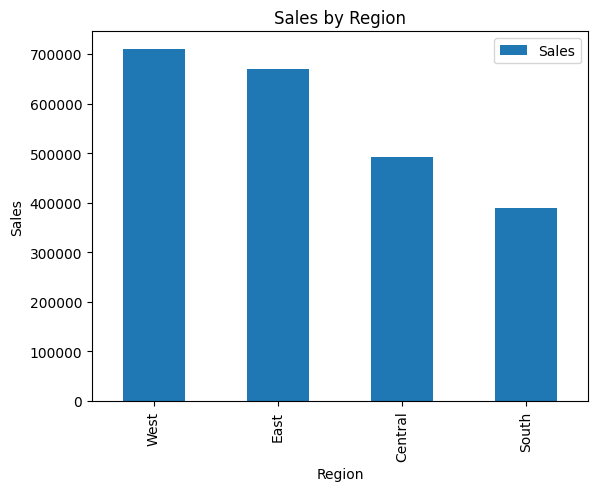

In [ ]:
plt.figure()
Sales_by_region.plot(x = 'Region' , y = 'Sales' , kind = 'bar')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales by Region')
plt.show()

In [ ]:
Sales_per_Customer = df.groupby('Customer ID')['Sales'].sum().reset_index()

In [ ]:
Sales_per_Customer.sort_values(by='Sales', ascending = False)

,Customer ID,Sales
700,SM-20320,25043.050
741,TC-20980,19052.218
621,RB-19360,15117.339
730,TA-21385,14595.620
6,AB-10105,14473.571
...,...,...
508,MG-18205,16.739
145,CJ-11875,16.520
681,SC-20845,14.112
456,LD-16855,5.304


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order_Month', 'Order_Year', 'Order_Day'],
      dtype='object')

Checking Order Date and Ship Date Columns

In [ ]:
df[['Order Date' , 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order_Month', 'Order_Year', 'Order_Day'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
df.shape

(9800, 21)

Converting Dates to Datetime

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
df['shiping_days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [ ]:
df['shiping_days'].head()

,shiping_days
0,3
1,3
2,4
3,7
4,7


In [ ]:
df[['Order Date' ,'Order_Year' , 'Order_Month' ,'Ship Date', 'shiping_days']].head()

,Order Date,Order_Year,Order_Month,Ship Date,shiping_days
0,2017-11-08,2017,2017-11,2017-11-11,3
1,2017-11-08,2017,2017-11,2017-11-11,3
2,2017-06-12,2017,2017-06,2017-06-16,4
3,2016-10-11,2016,2016-10,2016-10-18,7
4,2016-10-11,2016,2016-10,2016-10-18,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

Converting Order Month from period to Interger for Machine Learning

In [ ]:
df['Order_Month'] = df['Order Date'].dt.month

In [ ]:
df['Order_Month'].head()

,Order_Month
0,11
1,11
2,6
3,10
4,10


In [ ]:
df.shiping_days.head()

,shiping_days
0,3
1,3
2,4
3,7
4,7


Preparing Data for machine Learning Separating Categorical Features and Numerical Features

In [ ]:
Categorical_Features = ['Ship Mode' , 'Segment' , 'Country' , 'City' , 'State' , 'Region' , 'Category' , 'Sub-Category']

In [ ]:
Numerical_Features = ['Order_Month' , 'Order_Year','shiping_days' , 'Order_Day']

Using OneHotEncoder to change categorical values to Numerical values For Machine Learning

In [ ]:
processor = ColumnTransformer(
    transformers = [('num' , 'passthrough' , Numerical_Features ) ,
        ('categorical' , OneHotEncoder(handle_unknown='ignore') , Categorical_Features)
    ]
, remainder = 'passthrough')

Separating independent and dependent variables for Machine Learning

In [ ]:
X = df[Categorical_Features + Numerical_Features]
y = df['Sales']

In [ ]:
processor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', 'passthrough',
                                 ['Order_Month', 'Order_Year', 'shiping_days',
                                  'Order_Day']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Ship Mode', 'Segment', 'Country', 'City',
                                  'State', 'Region', 'Category',
                                  'Sub-Category'])])

Spliting Data for Training and testing , will use 80% for training and 20% for testing

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size = 0.2 , random_state = 42)

In [ ]:
print("Train data :" , X_train.shape)
print("Test data : " , X_test.shape)

Train data : (7840, 12)
Test data :  (1960, 12)


setting up Random Forest Regressor Model

In [ ]:
model = RandomForestRegressor(n_estimators=100 , random_state=42 , n_jobs=-1)

fitting a model and Processor to a pipeline

In [ ]:
model_pipeline  = Pipeline(
    steps = [
        ('processor' , processor),
        ('model' , model)
    ]
)

In [ ]:
model_pipeline

Pipeline(steps=[('processor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['Order_Month', 'Order_Year',
                                                   'shiping_days',
                                                   'Order_Day']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Ship Mode', 'Segment',
                                                   'Country', 'City', 'State',
                                                   'Region', 'Category',
                                                   'Sub-Category'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
model_pipeline.fit(X_train , y_train)

Pipeline(steps=[('processor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['Order_Month', 'Order_Year',
                                                   'shiping_days',
                                                   'Order_Day']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Ship Mode', 'Segment',
                                                   'Country', 'City', 'State',
                                                   'Region', 'Category',
                                                   'Sub-Category'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

predicting dependent variables(y_pred) using Independent varaiables(X_test)

In [ ]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
y_pred

array([ 81.58164   ,  45.80194933, 311.85140667, ...,  34.39551333,
        25.41577   , 399.66418   ])

Comparing Actual and Pridicted Sales

In [ ]:
comparison = pd.DataFrame({'Actual' : y_test , 'Predicted' : y_pred})

In [ ]:
comparison.head()

,Actual,Predicted
532,47.94,81.581640
872,11.36,45.801949
1149,10.95,311.851407
2287,17.48,236.161960
4038,21.12,70.394580


ploting y_test and y_pred

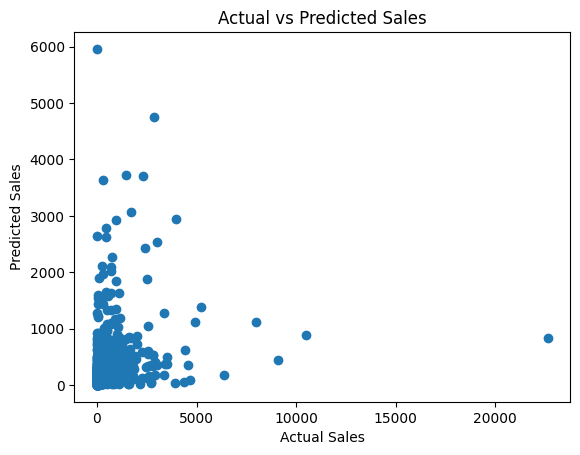

In [ ]:
plt.scatter(y_test , y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

checking how far my model prediction are from actual sales by Calculating Mean Squared Error

In [ ]:
mse = mean_squared_error(y_test , y_pred)
print("MSE:" , mse)

MSE: 640105.3001656032


Checking how far my model predictions are from the Mean by calculating Root Squred Eerror.

In [ ]:
RMSE = np.sqrt(mse)

In [ ]:
print('MSE :' , mse)
print('RMSE: ' , RMSE)

MSE : 640105.3001656032
RMSE:  800.0658098966629


Checking how the model explain variation in Sales

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2 = r2_score(y_test , y_pred)
print('R2 Score :' , r2)

R2 Score : 0.04233170269746023


Checking predition made by trained Data

In [ ]:
train_pred = model_pipeline.predict(X_train)
test_pred = model_pipeline.predict(X_test)

Trained Score 84.71 and Test Score 4.23% , Model has a large gap between training and testing not Enough information to predit sales like on the features we don't have Quantity , Dscount and Profit Features that directly speak to sales. Model explains 84% trained Data and 4.23% on testing variation. It is a large difference indicating signs for Overfitting

In [ ]:
print('Train Score :' , r2_score(y_train , train_pred))
print('Test Score :' , r2_score(y_test , test_pred))

Train Score : 0.8471911507020434
Test Score : 0.04233170269746023


Convert dtype Period to Object